In [1]:
import pandas as pd

In [2]:
data={"Hours Studied":[1,2,3,4,5,6,7],
      "Exam Score":[50,55,65,70,75,80,85]}
df=pd.DataFrame(data)
df

,Hours Studied,Exam Score
0,1,50
1,2,55
2,3,65
3,4,70
4,5,75
5,6,80
6,7,85


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Hours Studied  7 non-null      int64
 1   Exam Score     7 non-null      int64
dtypes: int64(2)
memory usage: 244.0 bytes


In [4]:
df.isna().sum()

Hours Studied    0
Exam Score       0
dtype: int64

In [5]:
x=df.iloc[:,0:1]
y=df.iloc[:,-1]
print(x.shape)
print(y.shape)

(7, 1)
(7,)


In [6]:
# x=df[["Hours Studied"]]
# y=df[["Exam Score"]]
# print(x)
# print(y)

In [7]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x,y)
y_pred=lr.predict(x)
print(y_pred)

[50.89285714 56.78571429 62.67857143 68.57142857 74.46428571 80.35714286
 86.25      ]


In [8]:
diff=pd.DataFrame({"Actual":y,
                   "Predicted":y_pred})
diff

,Actual,Predicted
0,50,50.892857
1,55,56.785714
2,65,62.678571
3,70,68.571429
4,75,74.464286
5,80,80.357143
6,85,86.250000


In [9]:
print("Coefficient : ",lr.coef_)
print("Intercept : ",lr.intercept_)

Coefficient :  [5.89285714]
Intercept :  45.0


In [10]:
from sklearn import metrics
print("MAE : ",metrics.mean_absolute_error(y,y_pred))
print("MSE : ",metrics.mean_squared_error(y,y_pred))
print("R2 Score : ",metrics.r2_score(y,y_pred))

MAE :  1.2244897959183672
MSE :  1.9132653061224514
R2 Score :  0.9864130434782609


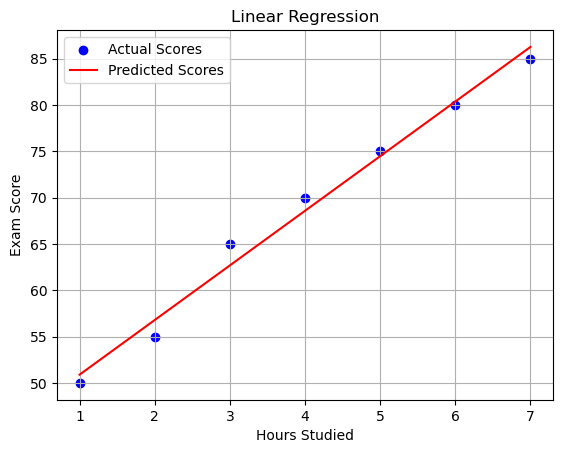

In [11]:
import matplotlib.pyplot as plt
plt.scatter(x,y,color="blue",label="Actual Scores")
plt.plot(x,y_pred,color="red",label="Predicted Scores")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
dataset=pd.read_csv("Book1.csv")
dataset

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [13]:
x=dataset.iloc[:,0:1]
y=dataset.iloc[:,-1]
print(x.shape)
print(y.shape)

(200, 1)
(200,)


In [14]:
print(type(x))
print(type(y))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [15]:
# split the data in form of training and testing.
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 1)
(40, 1)
(160,)
(40,)


In [16]:
x_train

,cgpa
108,7.76
107,6.33
189,8.11
14,7.73
56,5.84
...,...
133,6.05
137,7.14
72,7.78
140,7.91


In [17]:
y_train

108    3.54
107    2.59
189    4.06
14     3.42
56     2.74
       ... 
133    2.58
137    3.13
72     3.62
140    3.15
37     2.43
Name: package, Length: 160, dtype: float64

In [18]:
x_test

,cgpa
58,6.92
40,9.38
34,7.34
102,5.13
184,7.88
198,7.63
95,6.63
4,6.94
29,7.15
168,8.65


In [19]:
y_test

58     3.09
40     4.02
34     3.42
102    1.37
184    3.14
198    3.96
95     2.79
4      3.57
29     3.49
168    3.52
171    3.76
18     2.98
11     2.60
89     2.72
110    3.76
118    2.88
159    4.08
35     2.87
136    2.10
59     3.31
51     3.79
16     2.35
44     1.86
94     2.42
31     3.89
162    2.55
38     4.36
28     2.24
193    1.94
27     2.16
47     3.26
165    4.08
194    3.67
177    3.64
176    3.23
97     2.84
174    2.99
73     4.03
69     2.94
172    2.51
Name: package, dtype: float64

In [20]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
print(y_pred)

[2.9383335  4.36894346 3.18258398 1.89736121 3.49662031 3.35123312
 2.76968435 2.94996447 3.07208971 3.94441286 3.57222165 2.94996447
 2.75805338 2.64755911 3.67108494 3.2174769  3.97930579 2.90925606
 2.19395108 3.31052471 4.29915761 2.8918096  1.87409926 2.30444534
 3.62456104 2.12998071 3.9269664  2.36841571 1.5716939  2.06601035
 2.31026083 3.6885314  3.5024358  3.03719679 2.57195777 2.39167766
 3.170953   3.82228762 3.15932203 2.94414898]


In [21]:
diff=pd.DataFrame({"Actual":y_test,
                  "Predicted":y_pred})
print(diff)

     Actual  Predicted
58     3.09   2.938333
40     4.02   4.368943
34     3.42   3.182584
102    1.37   1.897361
184    3.14   3.496620
198    3.96   3.351233
95     2.79   2.769684
4      3.57   2.949964
29     3.49   3.072090
168    3.52   3.944413
171    3.76   3.572222
18     2.98   2.949964
11     2.60   2.758053
89     2.72   2.647559
110    3.76   3.671085
118    2.88   3.217477
159    4.08   3.979306
35     2.87   2.909256
136    2.10   2.193951
59     3.31   3.310525
51     3.79   4.299158
16     2.35   2.891810
44     1.86   1.874099
94     2.42   2.304445
31     3.89   3.624561
162    2.55   2.129981
38     4.36   3.926966
28     2.24   2.368416
193    1.94   1.571694
27     2.16   2.066010
47     3.26   2.310261
165    4.08   3.688531
194    3.67   3.502436
177    3.64   3.037197
176    3.23   2.571958
97     2.84   2.391678
174    2.99   3.170953
73     4.03   3.822288
69     2.94   3.159322
172    2.51   2.944149


In [22]:
print("Coefficient:",lr.coef_)
print("Intercept:",lr.intercept_)

Coefficient: [0.58154877]
Intercept: -1.0859839580358033


In [23]:
from sklearn import metrics
print("MAE : ",metrics.mean_absolute_error(y_test,y_pred))
print("MSE : ",metrics.mean_squared_error(y_test,y_pred))
print("R2 Score : ",metrics.r2_score(y_test,y_pred))

MAE :  0.29931188593316804
MSE :  0.1370062519255722
R2 Score :  0.7283345498058083


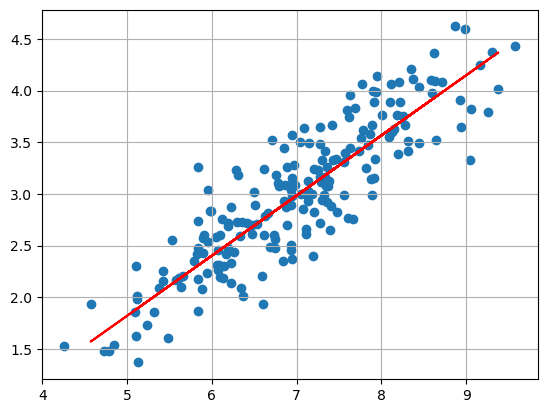

In [24]:
plt.scatter(dataset["cgpa"],dataset["package"])
plt.plot(x_test,y_pred,color="red")
plt.grid()
plt.show()

In [25]:
df=pd.read_csv("car data.csv")
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [26]:
df.shape

(301, 9)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [28]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [29]:
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [30]:
df["Age"]=2024-df["Year"]
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,10
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,8
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,9
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,15
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,7


In [32]:
df.drop("Year",axis=1,inplace=True)
df

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,10
...,...,...,...,...,...,...,...,...,...
296,city,9.50,11.60,33988,Diesel,Dealer,Manual,0,8
297,brio,4.00,5.90,60000,Petrol,Dealer,Manual,0,9
298,city,3.35,11.00,87934,Petrol,Dealer,Manual,0,15
299,city,11.50,12.50,9000,Diesel,Dealer,Manual,0,7


In [35]:
df=pd.get_dummies(data=df,drop_first=True)
df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Age,Car_Name_Activa 3g,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,Car_Name_Bajaj Avenger 150 street,...,Car_Name_swift,Car_Name_sx4,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,10,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
1,4.75,9.54,43000,0,11,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True
2,7.25,9.85,6900,0,7,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,2.85,4.15,5200,0,13,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True
4,4.60,6.87,42450,0,10,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,True


In [36]:
df.columns

Index(['Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner', 'Age',
       'Car_Name_Activa 3g', 'Car_Name_Activa 4g', 'Car_Name_Bajaj  ct 100',
       'Car_Name_Bajaj Avenger 150', 'Car_Name_Bajaj Avenger 150 street',
       ...
       'Car_Name_swift', 'Car_Name_sx4', 'Car_Name_verna',
       'Car_Name_vitara brezza', 'Car_Name_wagon r', 'Car_Name_xcent',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual',
       'Transmission_Manual'],
      dtype='object', length=106)